In [2]:
import pandas as pd

# Make plots for three bars
import matplotlib.pyplot as plt
import os
from pathlib import Path
import src.amr_utility.name_utility as name_utility

### Instead create results for LGR and XGB separately

In [3]:
# Open the results file
out_path = "./chandar_best_results.csv"
df = pd.read_csv("results_xgb_lgr_combined_20250923.csv")

df.drop(columns=['difficulty', 'clustering'], inplace=True)

# average all rows with the same: model_name,pathogen,pathogen_short,antibiotic,k,feat_mode,max_features,seed,split_method,clustering
group_cols = ['model_name','pathogen','pathogen_short','antibiotic','k','feat_mode','max_features','seed','split_method']
df_avg = df.groupby(group_cols, as_index=False).mean()
df_avg.drop(columns=["fold"], inplace=True)
df_avg.columns = [col if col in group_cols else f"mean_{col}" for col in df_avg.columns]
# Add column to each row with standard deviation of f1_macro for each group
df_std = df.groupby(group_cols, as_index=False).std()
df_std.drop(columns=["fold"], inplace=True)
df_std.columns = [col if col in group_cols else f"std_{col}" for col in df_std.columns]
df_avg = pd.merge(df_avg, df_std, on=group_cols, how='left')

# Drop all columns with clustering not equal to 'heirarchical'
df_avg = df_avg[df_avg['split_method'] == 'phylo']

# Only include models that have k=31
best_models = df_avg[df_avg['k'] == 31]
best_models = best_models[best_models['pathogen'] == 'escherichia_coli']
# Find the model with the highest mean_f1_macro for each pathogen and antibiotic combination
#best_models = df_avg.loc[df_avg.groupby(['model_name','pathogen','antibiotic'])['mean_f1_macro'].idxmax()]
print(best_models)
# Save the best models to a new CSV file
#best_models.to_csv(out_path, index=False)

    model_name          pathogen pathogen_short  antibiotic   k feat_mode  \
18         LGR  escherichia_coli         e_coli    cefepime  31     count   
26         LGR  escherichia_coli         e_coli  cefotaxime  31     count   
34         LGR  escherichia_coli         e_coli    imipenem  31     count   
90         XGB  escherichia_coli         e_coli    cefepime  31     count   
98         XGB  escherichia_coli         e_coli  cefotaxime  31     count   
106        XGB  escherichia_coli         e_coli    imipenem  31     count   

    max_features  seed split_method  mean_balanced_accuracy  mean_f1_macro  \
18         1000K    42        phylo                0.653397       0.669580   
26         1000K    42        phylo                0.707286       0.689187   
34         1000K    42        phylo                0.532231       0.523472   
90         1000K    42        phylo                0.670539       0.687961   
98         1000K    42        phylo                0.756683       0.73

In [6]:
# NICE PLOTS STUFF from ChatGPT
plt.rcParams.update({
    "font.size": 12,
})

species = ['Escherichia coli', 'Klebsiella pneumoniae', 'Acinetobacter baumannii',
           'Staphylococcus aureus', 'Pseudomonas aeruginosa']
species_drugs = []
all_resfinder_f1s = {}
all_aytan_f1s = {}

# Open the resfinder results for each species
all_resfinder_dataframes = []
for sp in species:
    file_path = name_utility.GETname_ResfinderResults(sp, "resfinder_b", "./") + ".csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, delimiter="\t", index_col=0)
        all_resfinder_dataframes.append(df)
        # Get the list of drugs for this species
        drugs = df.index.tolist()
        for drug in drugs:
            species_drugs.append((sp, drug))
            all_resfinder_f1s[(sp, drug)] = (df.loc[drug, 'f1_macro'])
    else:
        print(f"Warning: {file_path} does not exist and will be skipped.")

# Open the aytan-aktug results for each species
aytan_aktug_data = {}
for sp in species:
    file_format = name_utility.GETname_AAresult("AytanAktug",sp,0.0, 0,True,False,"f1_macro",False,True,"SSSA","./")
    metrics_file = Path(file_format + "_SummaryBenchmarking_PLOT.txt")
    stds_file = Path(file_format + "_SummaryBenchmarking_std.txt")
    if os.path.exists(metrics_file):
        if not os.path.exists(stds_file):
            print(f"Warning: {stds_file} does not exist. Standard deviations will not be available.")
        f1_df = pd.read_csv(metrics_file, delimiter="\t", index_col=0)
        stds_df = pd.read_csv(stds_file, delimiter="\t", index_col=0)
        # Merge the two dataframes on the index (drug names)
        df = pd.merge(f1_df, stds_df, left_index=True, right_index=True, suffixes=('', '_std'))
        # Get the list of drugs for this species
        drugs = df.index.tolist()
        for drug in drugs:
            aytan_aktug_data[(sp, drug)] = (df.loc[drug, 'f1_macro'], df.loc[drug, 'f1_macro_std'])
    else:
        print(f"Warning: {metrics_file} does not exist and will be skipped.")

# Create one dataframe with all results, add column for model type

all_results = pd.DataFrame(columns=['model_name', 'pathogen', 'pathogen_short', 'antibiotic', 'mean_f1_macro', 'std_f1_macro'])
for (sp, drug), f1 in all_resfinder_f1s.items():
    pathogen = sp.lower().replace(" ", "_")
    antibiotic = drug.lower().replace(" ", "_").replace("-", "_")
    pathogen_short = pathogen.split("_")[0][0] + "_" + pathogen.split("_")[1]
    new_df = pd.DataFrame({
        'model_name': ['ResFinder'],
        'pathogen': [pathogen],
        'pathogen_short': [pathogen_short],
        'antibiotic': [antibiotic],
        'mean_f1_macro': [f1],
        'std_f1_macro': [0.0]
    })
    all_results = pd.concat([all_results, new_df], ignore_index=True)

for (sp, drug), (f1, f1_std) in aytan_aktug_data.items():
    pathogen = sp.lower().replace(" ", "_")
    antibiotic = drug.lower().replace(" ", "_").replace("-", "_")
    pathogen_short = pathogen.split("_")[0][0] + "_" + pathogen.split("_")[1]
    new_df = pd.DataFrame({
        'model_name': ['Aytan-Aktug'],
        'pathogen': [pathogen],
        'pathogen_short': [pathogen_short],
        'antibiotic': [antibiotic],
        'mean_f1_macro': [f1],
        'std_f1_macro': [f1_std]
    })
    all_results = pd.concat([all_results, new_df], ignore_index=True)

# Save results to CSV
all_results.to_csv("results_baselines.csv", index=False)


/tmp/ipykernel_4063679/3022107478.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, new_df], ignore_index=True)


In [5]:
# Load the results for aytan aktug
ayten_aktug_results = name_utility.GETname_AAresult("AytanAktug","Escherichia coli",0.0, 0,True,False,"f1_macro",False,True,"SSSA","./") + "_SummaryBenchmarking_PLOT.txt"
ayten_df = pd.read_csv(ayten_aktug_results, delimiter="\t", index_col=0)
# Load the STDS
aytan_stds = pd.read_csv(ayten_aktug_results.replace("PLOT.txt", "std.txt"), delimiter="\t", index_col=0)
# extract the std for weighted-f1_macro
ayten_std = aytan_stds.loc['cefepime', 'weighted-f1_macro']
# extract resfinder and chandar f1_macro values for (Escherichia coli, cefepime)
resfinder_f1 = all_resfinder_f1s[('Escherichia coli', 'cefepime')]
lgr_f1 = chandar_data_lgr[('Escherichia coli', 'cefepime')][0]
xgb_f1 = chandar_data_xgb[('Escherichia coli', 'cefepime')][0]
lgr_std = chandar_data_lgr[('Escherichia coli', 'cefepime')][2]
xgb_std = chandar_data_xgb[('Escherichia coli', 'cefepime')][2]
# extract ayten weighted-f1_macro
ayten_f1 = ayten_df.loc['cefepime', 'weighted-f1_macro']
# Create a bar chart comparing the four methods
plt.figure(figsize=(8, 6), dpi=300)  # high resolution (300 dpi)
methods = ['ResFinder', 'Aytan-Aktug NN', 'Chandar LGR', 'Chandar XGB']
f1_scores = [resfinder_f1, ayten_f1, lgr_f1, xgb_f1]
plt.bar(methods, f1_scores, color=['#58508d', '#bc5090', '#ff6361', '#ffa600'])
plt.ylim(0, 1.05)
plt.ylabel('F1 Macro (Higher is better)', fontsize=14)
plt.title('F1 Macro Comparison for Escherichia coli and Cefepime', fontsize=16, fontweight='bold')
# Add error bars for Chandar models and aytan
plt.errorbar(2, lgr_f1, yerr=lgr_std, fmt='none', ecolor='black', capsize=5)
plt.errorbar(3, xgb_f1, yerr=xgb_std, fmt='none', ecolor='black', capsize=5)
plt.errorbar(1, ayten_f1, yerr=ayten_std, fmt='none', ecolor='black', capsize=5)

# Add dashed lines every 0.2 from 0 to 1.0
for y in range(0, 11, 2):  # 0, 2, 4, 6, 8, 10
    y = y / 10.0
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Value labels above bars
for i, v in enumerate(f1_scores):
    if i >= 1:
        plt.text(i-0.25, v +0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
        # add k value below the f1 score
        if i >= 2:
            k_value = chandar_data_lgr[('Escherichia coli', 'cefepime')][1] if i == 2 else chandar_data_xgb[('Escherichia coli', 'cefepime')][1]
            plt.text(i-0.25, v - 0.04, f"(k={k_value})", ha='center', va='bottom', fontsize=8, color='gray')
    else:
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
# Save high-quality PNG
plt.savefig("escherichia_coli_cefepime_f1_comparison.png", dpi=300, bbox_inches="tight")
print("Saved", "escherichia_coli_cefepime_f1_comparison.png")


KeyError: 'weighted-f1_macro'

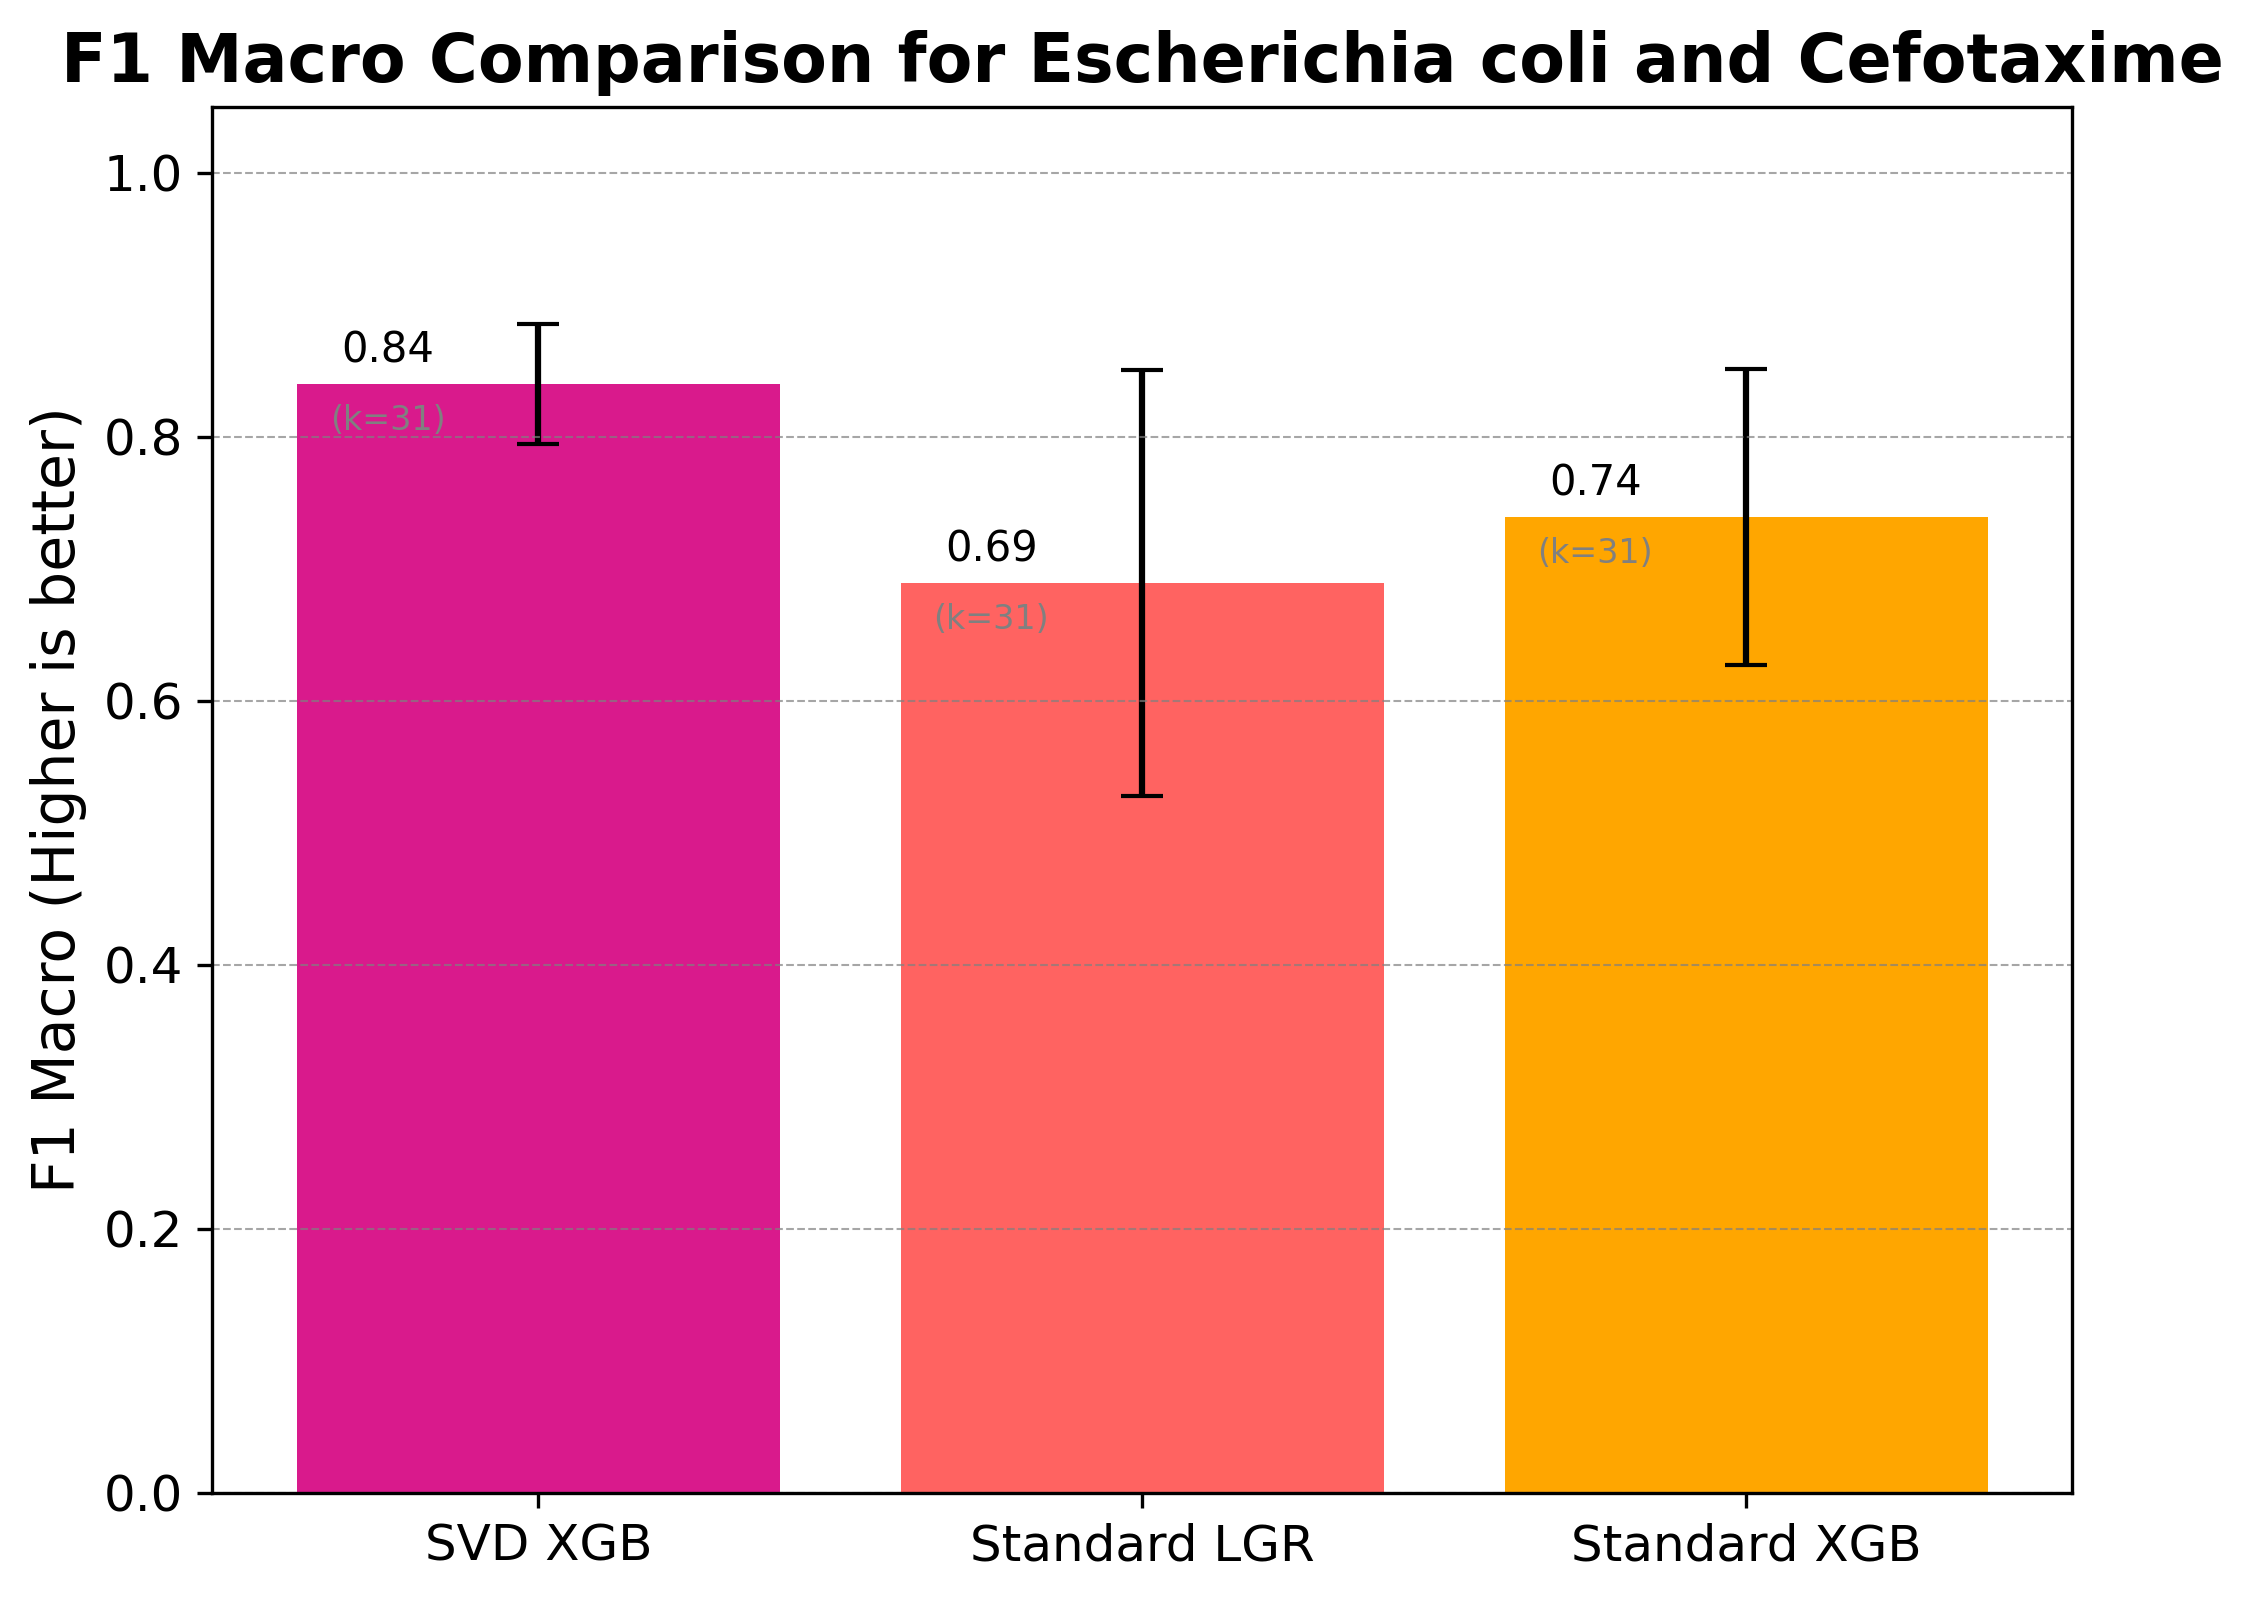

In [ ]:
# NICE PLOTS STUFF from ChatGPT
plt.rcParams.update({
    "font.size": 12,
})

# Data
methods = ["SVD XGB", "Standard LGR", "Standard XGB"]
f1_scores = [0.8399, 0.689187, 0.739149]
std_devs = [0.0456, 0.161129, 0.112200]

# X positions
x_pos = np.arange(len(methods))

# Create a bar chart comparing the four methods
plt.figure(figsize=(8, 6), dpi=300)  # high resolution (300 dpi)
plt.bar(methods, f1_scores, color=["#d91a8c", '#ff6361', '#ffa600'])
plt.ylim(0, 1.05)
plt.ylabel('F1 Macro (Higher is better)', fontsize=14)
plt.title('F1 Macro Comparison for Escherichia coli and Cefotaxime', fontsize=16, fontweight='bold')
# Add error bars
for i in range(len(methods)):
    plt.errorbar(i, f1_scores[i], yerr=std_devs[i], fmt='none', ecolor='black', capsize=5)

# Add dashed lines every 0.2 from 0 to 1.0
for y in range(0, 11, 2):  # 0, 2, 4, 6, 8, 10
    y = y / 10.0
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Value labels above bars
for i, v in enumerate(f1_scores):
    plt.text(i-0.25, v +0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
    # add k value below the f1 score
    plt.text(i-0.25, v - 0.04, f"(k=31)", ha='center', va='bottom', fontsize=8, color='gray')

# Save high-quality PNG
plt.show()
# plt.savefig("escherichia_coli_cefepime_f1_comparison.png", dpi=300, bbox_inches="tight")
# print("Saved", "escherichia_coli_cefepime_f1_comparison.png")

